# New York Taxi Data Processing
This notebook presents a data processing workflow for New York City taxi trip data.  
It includes data loading, cleaning, feature engineering, exploratory analysis, and preparation for downstream analytics.

## 1. Objective

The main goal is to transform raw taxi trip records into a cleaner and more informative dataset by creating features related to time and distance, which can support further analysis and modeling.

## 2. Import Libraries
This section imports the core libraries used throughout the notebook for data analysis and visualization.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Feature engineering
from haversine import haversine_vector

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.2)
  from scipy.stats import gaussian_kde


## 3. Load Data
This section loads the processed dataset and performs an initial inspection to verify its structure, dimensions, data types, and missing values.

In [4]:
# Load the processed dataset
df = pd.read_csv("../data/raw/train.csv")

# Display dataset dimensions
print(f"Dataset shape: {df.shape}")

# Inspect column names
print("Columns:")
print(df.columns.tolist())

# Inspect data types and missing values
print(df.info())

# Preview the first rows
df.head()

Dataset shape: (1458644, 11)
Columns:
['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']
<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## 4. Transform Data
This section applies basic transformations to prepare the dataset for analysis, including datetime conversion and filtering of invalid records.

### 4.1 Convert Date Columns

In [5]:
# Convert date columns to datetime format
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"])

# Verify conversion
df[["pickup_datetime", "dropoff_datetime"]].dtypes

pickup_datetime     datetime64[us]
dropoff_datetime    datetime64[us]
dtype: object

### 4.2 Filter Invalid Records

In [8]:
# Keep only trips with valid NYC pickup coordinates
df = df[
    df["pickup_longitude"].between(-74.05, -73.75) &
    df["pickup_latitude"].between(40.63, 40.85) &
    df["dropoff_longitude"].between(-74.05, -73.75) &
    df["dropoff_latitude"].between(40.63, 40.85)
]

# Remove trips with unrealistic duration values
df = df[df["trip_duration"].between(60, 3600 * 3)]  # between 1 minute and 3 hours

## 5. Generate Features
In this step, new variables are derived from the existing trip data to enrich the dataset. These features include travel distance in kilometers, pickup hour, and day of week.

### 5.1 Distance Feature
This section creates new variables from the trip records to enrich the dataset for analysis. The generated features include trip distance in kilometers, pickup hour, and weekday.

In [10]:
# Calculate trip distance in kilometers using the haversine formula
from haversine import haversine_vector, Unit

df["distance_km"] = haversine_vector(
    df[["pickup_latitude", "pickup_longitude"]].to_numpy(),
    df[["dropoff_latitude", "dropoff_longitude"]].to_numpy(),
    unit=Unit.KILOMETERS
)


### 5.2 Time-Based Features
Additional temporal variables are extracted from the pickup timestamp, including hour of day and day of week.

In [11]:
# Extract time-based features
df["hour"] = df["pickup_datetime"].dt.hour
df["weekday"] = df["pickup_datetime"].dt.weekday

# Summary of generated features
df[["distance_km", "hour", "weekday"]].describe()

,distance_km,hour,weekday
count,1.429750e+06,1.429750e+06,1.429750e+06
mean,3.313221e+00,1.362054e+01,3.048104e+00
std,3.668932e+00,6.378443e+00,1.953308e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.236695e+00,9.000000e+00,1.000000e+00
50%,2.081028e+00,1.400000e+01,3.000000e+00
75%,3.786295e+00,1.900000e+01,5.000000e+00
max,2.719167e+01,2.300000e+01,6.000000e+00


In [ ]:
# Use haversine function to calculate the distance between point A(pickup) and B(dropoff). 
# The result will be store in a new column "distance_km". There will be also two additional columns "hour" and "weekday"

from haversine import haversine_vector, Unit

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Distance traveled in km (vectors)
df['distance_km'] = haversine_vector(
    df[['pickup_latitude', 'pickup_longitude']].to_numpy(),
    df[['dropoff_latitude', 'dropoff_longitude']].to_numpy(),
    unit=Unit.KILOMETERS
)

# Hour and day of the week
df['hour'] = df['pickup_datetime'].dt.hour
df['weekday'] = df['pickup_datetime'].dt.weekday

## 6. Validate Data
This section validates the transformed dataset by checking for missing values, verifying data types, and identifying duplicate records.

### 6.1 Basic Validation
Basic quality checks help confirm that the dataset is clean and structurally consistent before further analysis.

In [12]:
# Check missing values
print("Missing values by column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nNumber of duplicated rows:")
print(df.duplicated().sum())

Missing values by column:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
distance_km           0
hour                  0
weekday               0
dtype: int64

Data types:
id                               str
vendor_id                      int64
pickup_datetime       datetime64[us]
dropoff_datetime      datetime64[us]
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag               str
trip_duration                  int64
distance_km                  float64
hour                           int32
weekday                        int32
dtype: object

Number of duplicated rows:
0


#### 6.2 Distance Validation

In [14]:
# Validate distance feature
print("Negative distance values:")
print((df["distance_km"] < 0).sum())

print("\nDistance summary statistics:")
print(df["distance_km"].describe())

from haversine import haversine
print("\nSample geographic sanity check (JFK to Manhattan, km):")
print(haversine((40.761, -73.979), (40.641, -73.778)))

Negative distance values:
0

Distance summary statistics:
count    1.429750e+06
mean     3.313221e+00
std      3.668932e+00
min      0.000000e+00
25%      1.236695e+00
50%      2.081028e+00
75%      3.786295e+00
max      2.719167e+01
Name: distance_km, dtype: float64

Sample geographic sanity check (JFK to Manhattan, km):
21.5673898637674


### 6.3 Time Feature Validation

In [15]:
# Validate time-based features
print("Invalid hour values:")
print(((df["hour"] < 0) | (df["hour"] > 23)).sum())

print("\nHour summary statistics:")
print(df["hour"].describe())

print("\nInvalid weekday values:")
print(((df["weekday"] < 0) | (df["weekday"] > 6)).sum())

print("\nWeekday summary statistics:")
print(df["weekday"].describe())

Invalid hour values:
0

Hour summary statistics:
count    1.429750e+06
mean     1.362054e+01
std      6.378443e+00
min      0.000000e+00
25%      9.000000e+00
50%      1.400000e+01
75%      1.900000e+01
max      2.300000e+01
Name: hour, dtype: float64

Invalid weekday values:
0

Weekday summary statistics:
count    1.429750e+06
mean     3.048104e+00
std      1.953308e+00
min      0.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      5.000000e+00
max      6.000000e+00
Name: weekday, dtype: float64


### 6.4 Quick Cross Validation
This subsection performs a few quick consistency checks on the engineered features by reviewing zero-distance trips and inspecting extreme distance values.

In [16]:
# Quick cross-validation checks
print("Trips with zero computed distance:")
print((df["distance_km"] == 0).sum())

print("\nTop 5 longest trips:")
print(df.nlargest(5, "distance_km")[["id", "pickup_datetime", "dropoff_datetime", "distance_km", "trip_duration"]])

print("\nTop 5 shortest trips:")
print(df.nsmallest(5, "distance_km")[["id", "pickup_datetime", "dropoff_datetime", "distance_km", "trip_duration"]])

Trips with zero computed distance:
3989

Top 5 longest trips:
                id     pickup_datetime    dropoff_datetime  distance_km  \
87724    id1896190 2016-04-29 06:12:36 2016-04-29 06:58:11    27.191667   
181710   id1840427 2016-05-14 04:36:58 2016-05-14 05:12:26    26.591853   
1140932  id1537489 2016-04-02 13:42:58 2016-04-02 14:49:32    26.502242   
311326   id3834115 2016-02-18 17:59:10 2016-02-18 18:52:13    26.457568   
810978   id2021120 2016-05-12 07:35:03 2016-05-12 08:23:54    26.351351   

         trip_duration  
87724             2735  
181710            2128  
1140932           3994  
311326            3183  
810978            2931  

Top 5 shortest trips:
             id     pickup_datetime    dropoff_datetime  distance_km  \
246   id3487442 2016-02-29 18:39:12 2016-02-29 18:42:59          0.0   
291   id0924324 2016-05-10 18:07:52 2016-05-10 18:26:21          0.0   
407   id1145809 2016-05-16 23:15:13 2016-05-16 23:31:00          0.0   
702   id3499387 2016-01-25

## 7. Save in Parquet format
The validated dataset is saved in Parquet format to support efficient storage and fast analytical queries.

In [18]:
# Save transformed dataset in Parquet format
output_path = "../data/processed/nyc_taxi_features.parquet"

df.to_parquet(output_path, index=False)

print(f"Parquet file saved to: {output_path}")

Parquet file saved to: ../data/processed/nyc_taxi_features.parquet


## 8. Query the Parquet File with DuckDB

This section uses DuckDB to query the Parquet file and perform a simple aggregation of average trip distance by weekday.

In [22]:
import duckdb
# Query the Parquet file with DuckDB
query = """
SELECT 
    weekday,
    ROUND(AVG(distance_km), 2) AS avg_distance_km
FROM read_parquet('../data/processed/nyc_taxi_features.parquet')
GROUP BY weekday
ORDER BY weekday
"""

result = duckdb.query(query).df()

print("Average trip distance by weekday:")
print(result)

Average trip distance by weekday:
   weekday  avg_distance_km
0        0             3.44
1        1             3.22
2        2             3.22
3        3             3.29
4        4             3.27
5        5             3.21
6        6             3.58


## 9. Generate visualizations
This section presents a small set of visualizations to summarize the main characteristics of the transformed dataset.

### 9.1 Distribution of Trip Duration

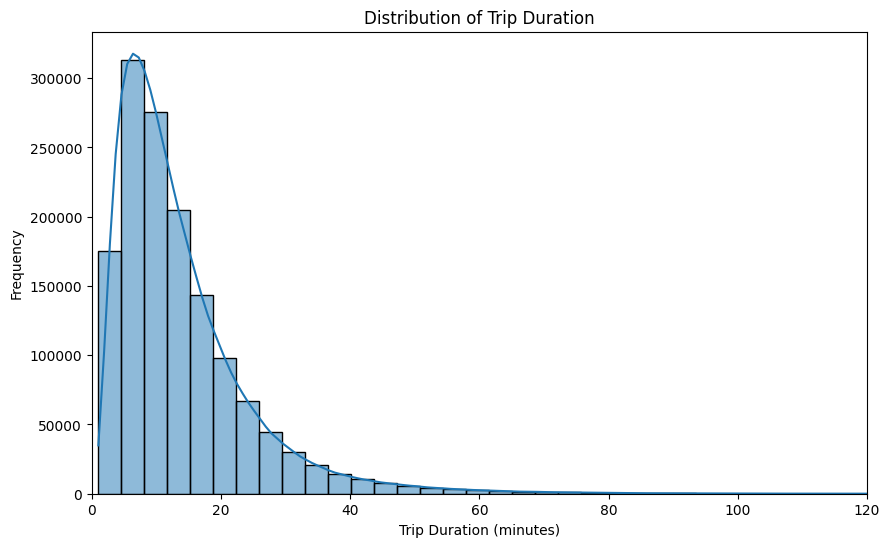

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed dataset from Parquet for visualization
viz_df = pd.read_parquet("../data/processed/nyc_taxi_features.parquet")
                                  
plt.figure(figsize=(10, 6))
sns.histplot(viz_df["trip_duration"] / 60, bins=50, kde=True)

plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Frequency")
plt.xlim(0, 120)
plt.show()

The distribution is right-skewed, indicating that most trips are relatively short while a smaller number of trips have much longer durations.

### 9.2 Distance vs Trip Duration

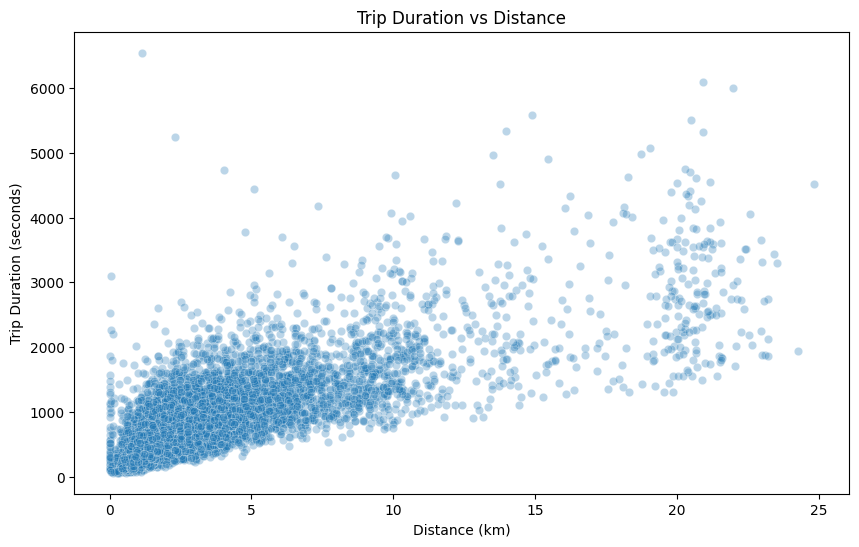

In [27]:
sample_df = viz_df.sample(min(10000, len(viz_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df,
    x="distance_km",
    y="trip_duration",
    alpha=0.3
)

plt.title("Trip Duration vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Trip Duration (seconds)")
plt.show()

A positive relationship is visible between distance and trip duration, in general, longer trips take more time. However, the spread of the points suggests that trips with similar distances can still have different durations.

### 9.3 Average Distance by Hour

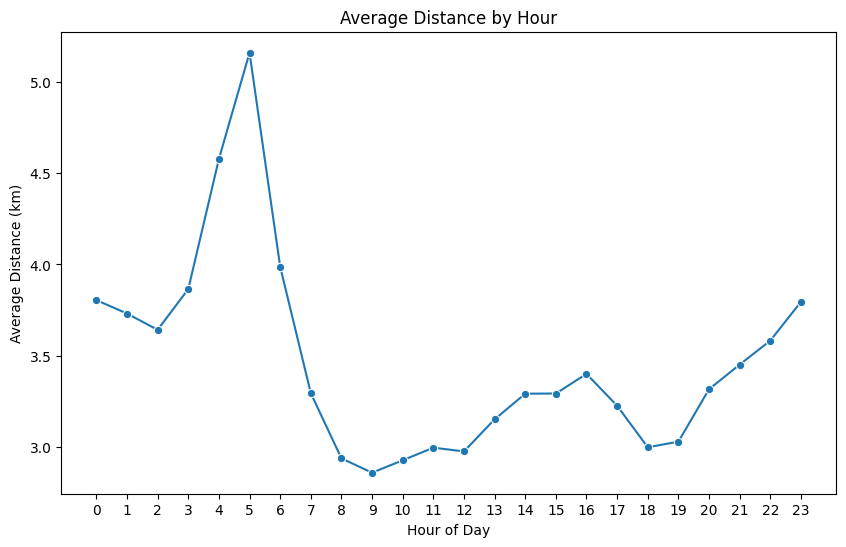

In [28]:
hourly_distance = viz_df.groupby("hour")["distance_km"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_distance, x="hour", y="distance_km", marker="o")

plt.title("Average Distance by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Distance (km)")
plt.xticks(range(0, 24))
plt.show()

Average trip distance varies across the day, which may reflect changes in travel demand patterns and trip purpose by hour.

### 9.4 Correlation Heatmap

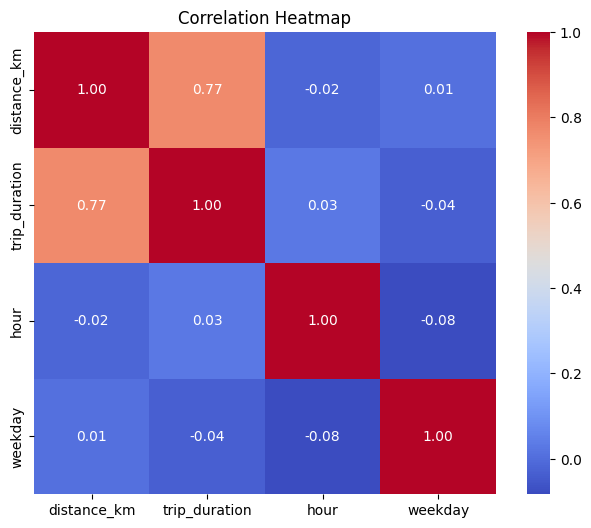

In [29]:
corr = viz_df[["distance_km", "trip_duration", "hour", "weekday"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.title("Correlation Heatmap")
plt.show()

Distance shows the strongest positive correlation with trip duration, while hour and weekday exhibit weaker linear relationships.